In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [11]:
import pandas as pd

file_path = "~/Downloads/diabetes_brfss/diabetes_012_health_indicators_BRFSS2015.csv"

df = pd.read_csv(file_path)
df.head()


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
from sklearn.pipeline import Pipeline

In [14]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [15]:
y = df["Diabetes_012"]

X = df.drop("Diabetes_012", axis=1)

In [16]:
print(X.shape)
print(y.shape)

(253680, 21)
(253680,)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y
)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [19]:
X_train_scaled = scaler.fit_transform(X_train)

In [20]:
X_test_scaled = scaler.fit_transform(X_test)

In [21]:
model = LogisticRegression(max_iter=1000)

In [22]:
model.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [23]:
predictions = model.predict(X_test_scaled)

In [24]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, predictions)
print("ACCURACY:", accuracy)

ACCURACY: 0.8455731630400505


In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

         0.0       0.86      0.97      0.91     42741
         1.0       0.00      0.00      0.00       926
         2.0       0.52      0.18      0.26      7069

    accuracy                           0.85     50736
   macro avg       0.46      0.38      0.39     50736
weighted avg       0.80      0.85      0.81     50736



/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

print(cm)

[[41662     0  1079]
 [  839     0    87]
 [ 5830     0  1239]]


In [27]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[float64](3,)","[0.,1.,2.]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [28]:
knn_predictions = knn.predict(X_test_scaled)

In [29]:
from sklearn.metrics import classification_report
print(classification_report(y_test, knn_predictions))

              precision    recall  f1-score   support

         0.0       0.86      0.95      0.91     42741
         1.0       0.06      0.00      0.00       926
         2.0       0.42      0.21      0.28      7069

    accuracy                           0.83     50736
   macro avg       0.45      0.39      0.40     50736
weighted avg       0.79      0.83      0.80     50736



In [30]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, knn_predictions))

[[40774    20  1947]
 [  812     2   112]
 [ 5590    12  1467]]


In [31]:
from sklearn.tree import DecisionTreeClassifier 
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [32]:
dt_predictions = dt.predict(X_test)


In [33]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, dt_predictions))

[[36584   900  5257]
 [  667    36   223]
 [ 4509   283  2277]]


In [34]:
from sklearn.metrics import classification_report
print(classification_report(y_test, dt_predictions))

              precision    recall  f1-score   support

         0.0       0.88      0.86      0.87     42741
         1.0       0.03      0.04      0.03       926
         2.0       0.29      0.32      0.31      7069

    accuracy                           0.77     50736
   macro avg       0.40      0.41      0.40     50736
weighted avg       0.78      0.77      0.77     50736



In [35]:
from sklearn.ensemble import RandomForestClassifier

In [36]:
rf_model = RandomForestClassifier(random_state=42)


In [37]:
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [38]:
rf_predictions = rf_model.predict(X_test)

In [39]:
from sklearn.metrics import classification_report
print (classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

         0.0       0.86      0.97      0.91     42741
         1.0       0.00      0.00      0.00       926
         2.0       0.50      0.20      0.28      7069

    accuracy                           0.84     50736
   macro avg       0.45      0.39      0.40     50736
weighted avg       0.80      0.84      0.81     50736



In [40]:
from sklearn.metrics import confusion_matrix
print (confusion_matrix(y_test, rf_predictions))

[[41364    47  1330]
 [  832     0    94]
 [ 5666     7  1396]]


In [41]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear', random_state=42)

In [42]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    random_state=42,
    cache_size=2000
)

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "LogisticRegression": predictions,
    "KNN": knn_predictions,
    "Decision Tree": dt_predictions,
    "Random Forest": rf_predictions
}
for name, prediction in models.items():
    print(f"\n{name}")
    print("Accuracy :", accuracy_score(y_test, prediction))
    print("Precision:", precision_score(y_test, prediction, average="weighted"))
    print("Recall   :", recall_score(y_test, prediction, average="weighted"))
    print("F1 Score :", f1_score(y_test, prediction, average="weighted"))


LogisticRegression
Accuracy : 0.8455731630400505
Precision: 0.7979565945599103
Recall   : 0.8455731630400505
F1 Score : 0.8071929060651151

KNN
Accuracy : 0.8326040681173131
Precision: 0.7871411494137316
Recall   : 0.8326040681173131
F1 Score : 0.8026710967677905

Decision Tree
Accuracy : 0.7666548407442447
Precision: 0.7794425890881926
Recall   : 0.7666548407442447
F1 Score : 0.7728463841267643

Random Forest
Accuracy : 0.8427940712708925
Precision: 0.7970210482630233
Recall   : 0.8427940712708925
F1 Score : 0.8085357740327664


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [44]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_scaled, y_train)

lr_prob = lr_model.predict_proba(X_test_scaled)

In [45]:
print(lr_prob.shape)

(50736, 3)


In [46]:
from sklearn.metrics import roc_auc_score

lr_auc = roc_auc_score(
    y_test,
    lr_prob,
    multi_class="ovr"
)

roc_auc = roc_auc_score(
    y_test,
    lr_prob,
    multi_class="ovr",
    average=None
)

print("Logistic Regression ROC-AUC:", lr_auc)
print("ROC-AUC for each class:", roc_auc)

Logistic Regression ROC-AUC: 0.7808737384280381
ROC-AUC for each class: [0.81520191 0.70777513 0.81964418]


In [47]:
from sklearn.metrics import roc_auc_score

knn_prob = knn.predict_proba(X_test_scaled)

knn_auc = roc_auc_score(
    y_test,
    knn_prob,
    multi_class="ovr"
)

knn_class_auc = roc_auc_score(
    y_test,
    knn_prob,
    multi_class="ovr",
    average=None
)

print("KNN ROC-AUC:", knn_auc)
print("KNN ROC-AUC for each class:", knn_class_auc)

KNN ROC-AUC: 0.6558521123840931
KNN ROC-AUC for each class: [0.72323737 0.52298635 0.72133262]


In [48]:
from sklearn.metrics import roc_auc_score

dt_prob = dt.predict_proba(X_test)

dt_auc = roc_auc_score(
    y_test,
    dt_prob,
    multi_class="ovr"
)

dt_class_auc = roc_auc_score(
    y_test,
    dt_prob,
    multi_class="ovr",
    average=None
)

print("Decision Tree ROC-AUC:", dt_auc)
print("Decision Tree ROC-AUC for each class:", dt_class_auc)

Decision Tree ROC-AUC: 0.5689155517496642
Decision Tree ROC-AUC for each class: [0.60327393 0.50586228 0.59761045]


In [49]:
from sklearn.metrics import roc_auc_score

rf_prob = rf_model.predict_proba(X_test)

rf_auc = roc_auc_score(
    y_test,
    rf_prob,
    multi_class="ovr"
)

rf_class_auc = roc_auc_score(
    y_test,
    rf_prob,
    multi_class="ovr",
    average=None
)

print("Random Forest ROC-AUC:", rf_auc)
print("Random Forest ROC-AUC for each class:", rf_class_auc)

Random Forest ROC-AUC: 0.739404591485051
Random Forest ROC-AUC for each class: [0.79226701 0.62861887 0.7973279 ]


In [50]:
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

# Interaction 1: Blood pressure + cholesterol risk
X_train_fe["BP_Chol_Interaction"] = X_train_fe["HighBP"] * X_train_fe["HighChol"]
X_test_fe["BP_Chol_Interaction"] = X_test_fe["HighBP"] * X_test_fe["HighChol"]

# Interaction 2: General health + physical health
X_train_fe["Health_Burden"] = X_train_fe["GenHlth"] * X_train_fe["PhysHlth"]
X_test_fe["Health_Burden"] = X_test_fe["GenHlth"] * X_test_fe["PhysHlth"]

# Interaction 3: BMI + physical activity
X_train_fe["BMI_Activity"] = X_train_fe["BMI"] * (1 - X_train_fe["PhysActivity"])
X_test_fe["BMI_Activity"] = X_test_fe["BMI"] * (1 - X_test_fe["PhysActivity"])

print("Original number of features:", X_train.shape[1])
print("New number of features:", X_train_fe.shape[1])

Original number of features: 21
New number of features: 24


In [51]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler_fe = StandardScaler()

X_train_fe_scaled = scaler_fe.fit_transform(X_train_fe)
X_test_fe_scaled = scaler_fe.transform(X_test_fe)

lr_fe = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_fe.fit(X_train_fe_scaled, y_train)

lr_fe_prediction = lr_fe.predict(X_test_fe_scaled)

print(confusion_matrix(y_test, lr_fe_prediction))
print(classification_report(y_test, lr_fe_prediction))

[[41700     0  1041]
 [  836     0    90]
 [ 5870     0  1199]]
              precision    recall  f1-score   support

         0.0       0.86      0.98      0.92     42741
         1.0       0.00      0.00      0.00       926
         2.0       0.51      0.17      0.26      7069

    accuracy                           0.85     50736
   macro avg       0.46      0.38      0.39     50736
weighted avg       0.80      0.85      0.81     50736



/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [52]:
from sklearn.metrics import roc_auc_score

lr_fe_prob = lr_fe.predict_proba(X_test_fe_scaled)

lr_fe_roc_auc = roc_auc_score(
    y_test,
    lr_fe_prob,
    multi_class="ovr",
    average="weighted"
)

print("Logistic Regression with Feature Engineering ROC-AUC:", lr_fe_roc_auc)

Logistic Regression with Feature Engineering ROC-AUC: 0.8139634212994228


In [53]:
X_train_fe2 = X_train_fe.copy()
X_test_fe2 = X_test_fe.copy()

X_train_fe2["BMI_squared"] = X_train_fe2["BMI"] ** 2
X_test_fe2["BMI_squared"] = X_test_fe2["BMI"] ** 2

X_train_fe2["Age_squared"] = X_train_fe2["Age"] ** 2
X_test_fe2["Age_squared"] = X_test_fe2["Age"] ** 2

X_train_fe2["GenHlth_squared"] = X_train_fe2["GenHlth"] ** 2
X_test_fe2["GenHlth_squared"] = X_test_fe2["GenHlth"] ** 2

print("Features after transformations:", X_train_fe2.shape[1])

Features after transformations: 27


In [54]:
scaler_fe2 = StandardScaler()

X_train_fe2_scaled = scaler_fe2.fit_transform(X_train_fe2)
X_test_fe2_scaled = scaler_fe2.transform(X_test_fe2)

lr_fe2 = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_fe2.fit(X_train_fe2_scaled, y_train)

lr_fe2_prob = lr_fe2.predict_proba(X_test_fe2_scaled)

lr_fe2_roc_auc = roc_auc_score(
    y_test,
    lr_fe2_prob,
    multi_class="ovr",
    average="weighted"
)

print("Logistic Regression after transformations ROC-AUC:", lr_fe2_roc_auc)

Logistic Regression after transformations ROC-AUC: 0.8187266253701169


In [55]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=15)

X_train_selected = selector.fit_transform(X_train_fe2_scaled, y_train)
X_test_selected = selector.transform(X_test_fe2_scaled)

print("Original features:", X_train_fe2_scaled.shape[1])
print("Selected features:", X_train_selected.shape[1])

Original features: 27
Selected features: 15


In [56]:
lr_selected = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_selected.fit(X_train_selected, y_train)

lr_selected_prob = lr_selected.predict_proba(X_test_selected)

lr_selected_roc_auc = roc_auc_score(
    y_test,
    lr_selected_prob,
    multi_class="ovr",
    average="weighted"
)

print("Logistic Regression after Feature Selection ROC-AUC:",
      lr_selected_roc_auc)

Logistic Regression after Feature Selection ROC-AUC: 0.8148074610557222


In [57]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lr_cv_scores = cross_val_score(
    lr_fe2,
    X_train_fe2_scaled,
    y_train,
    cv=cv,
    scoring="roc_auc_ovr_weighted",
    n_jobs=-1
)

print("Cross-validation ROC-AUC scores:")
print(lr_cv_scores)

print("Mean ROC-AUC:", lr_cv_scores.mean())
print("Standard deviation:", lr_cv_scores.std())

Cross-validation ROC-AUC scores:
[0.82213584 0.82319348 0.81707996 0.82426474 0.81753684]
Mean ROC-AUC: 0.8208421710572272
Standard deviation: 0.0029663332767319002


In [58]:
from sklearn.model_selection import GridSearchCV

In [59]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]
}

In [60]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42, max_iter=1000)

grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc_ovr",
    n_jobs=-1
)

In [61]:
grid_search.fit(X_train_fe_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc_ovr'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with

In [62]:
grid_search.best_params_

{'C': 0.01}

In [63]:
grid_search.best_score_

np.float64(0.7816227856321261)

In [64]:
grid_search.cv_results_["mean_test_score"]

array([0.78162279, 0.78157841, 0.78155541, 0.78155441, 0.78155413])

In [65]:
X_train_fe_scaled.shape


(202944, 24)

In [66]:
X_train_fe.shape

(202944, 24)

In [67]:
cv_scores

NameError: name 'cv_scores' is not defined

In [68]:
np.unique(y_train)

array([0., 1., 2.])

In [69]:
from sklearn.model_selection import cross_val_score

lr_cv = LogisticRegression(random_state=42, max_iter=1000)

cv_scores_new = cross_val_score(
    lr_cv,
    X_train_fe_scaled,
    y_train,
    cv=5,
    scoring="roc_auc_ovr"
)

cv_scores_new

array([0.77553284, 0.7826937 , 0.78538399, 0.78157992, 0.7825866 ])

In [70]:
cv_scores_new.mean()

np.float64(0.7815554124831195)

In [71]:
X_train_fe.columns

Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income',
       'BP_Chol_Interaction', 'Health_Burden', 'BMI_Activity'],
      dtype='str')

In [72]:
%whos

Variable                 Type                      Data/Info
------------------------------------------------------------
DecisionTreeClassifier   ABCMeta                   <class 'sklearn.tree._cla<...>.DecisionTreeClassifier'>
GridSearchCV             ABCMeta                   <class 'sklearn.model_sel<...>on._search.GridSearchCV'>
KNeighborsClassifier     ABCMeta                   <class 'sklearn.neighbors<...>on.KNeighborsClassifier'>
LogisticRegression       type                      <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
Pipeline                 ABCMeta                   <class 'sklearn.pipeline.Pipeline'>
RandomForestClassifier   ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
SVC                      ABCMeta                   <class 'sklearn.svm._classes.SVC'>
SelectKBest              ABCMeta                   <class 'sklearn.feature_s<...>e_selection.SelectKBest'>
StandardScaler           type                      <class 'skle

In [73]:
X_train_fe2.shape

(202944, 27)

In [74]:
from sklearn.pipeline import Pipeline

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(random_state=42, max_iter=1000))
])

In [75]:
param_grid = {
    "lr__C": [0.01, 0.1, 1, 10, 100]
}

In [76]:
grid_search_lr = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc_ovr",
    n_jobs=-1
)

In [77]:
grid_search_lr.fit(X_train_fe2, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'lr__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc_ovr'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, 

In [78]:
print("Best C:", grid_search_lr.best_params_)


Best C: {'lr__C': 0.01}


In [79]:
print("Best CV ROC-AUC:", grid_search_lr.best_score_)

Best CV ROC-AUC: 0.7849445404554305


In [80]:
best_lr = grid_search_lr.best_estimator_

best_lr_pred = best_lr.predict(X_test_fe2)

best_lr_prob = best_lr.predict_proba(X_test_fe2)

In [81]:
best_lr_roc_auc = roc_auc_score(
    y_test,
    best_lr_prob,
    multi_class="ovr"
)

print("Tuned Logistic Regression ROC-AUC:", best_lr_roc_auc)

Tuned Logistic Regression ROC-AUC: 0.7850404163330285


In [82]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20]
}

In [83]:
rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    cv=5,
    scoring="roc_auc_ovr",
    n_jobs=-1
)

rf_grid.fit(X_train_fe2, y_train)

print("Best parameters:", rf_grid.best_params_)
print("Best CV ROC-AUC:", rf_grid.best_score_)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters: {'max_depth': 10, 'n_estimators': 200}
Best CV ROC-AUC: 0.7828290009858277


In [84]:
best_rf = rf_grid.best_estimator_

rf_tuned_pred = best_rf.predict(X_test_fe2)

rf_tuned_prob = best_rf.predict_proba(X_test_fe2)

In [85]:
rf_tuned_roc_auc = roc_auc_score(
    y_test,
    rf_tuned_prob,
    multi_class="ovr"
)

print("Tuned Random Forest ROC-AUC:", rf_tuned_roc_auc)

Tuned Random Forest ROC-AUC: 0.7807430325842947


In [86]:
rf_fe = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    n_jobs=-1
)

rf_fe.fit(X_train_fe2, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [87]:
rf_fe_prob = rf_fe.predict_proba(X_test_fe2)

In [88]:
rf_fe_roc_auc = roc_auc_score(
    y_test,
    rf_fe_prob,
    multi_class="ovr"
)

print("Random Forest + Feature Engineering ROC-AUC:", rf_fe_roc_auc)

Random Forest + Feature Engineering ROC-AUC: 0.7336452277763866


In [89]:
scaler_knn_fe = StandardScaler()

X_train_knn_fe = scaler_knn_fe.fit_transform(X_train_fe2)
X_test_knn_fe = scaler_knn_fe.transform(X_test_fe2)

In [90]:
from sklearn.neighbors import KNeighborsClassifier
knn_fe = KNeighborsClassifier(n_neighbors=5)
knn_fe.fit(X_train_knn_fe, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[float64](3,)","[0.,1.,2.]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [91]:
knn_fe_prob = knn_fe.predict_proba(X_test_knn_fe)

In [92]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dt = DecisionTreeClassifier(random_state=42)

dt_param_grid = {
    "max_depth": [5, 10, 15, 20],
    "min_samples_leaf": [1, 5, 10]
}

In [93]:
dt_grid = GridSearchCV(
    estimator=dt,
    param_grid=dt_param_grid,
    cv=5,
    scoring="roc_auc_ovr",
    n_jobs=-1
)

dt_grid.fit(X_train_fe2, y_train)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc_ovr'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of inf

In [94]:
print("Best parameters:", dt_grid.best_params_)
print("Best CV ROC-AUC:", dt_grid.best_score_)

Best parameters: {'max_depth': 5, 'min_samples_leaf': 1}
Best CV ROC-AUC: 0.7634868468149014


In [95]:
best_dt = dt_grid.best_estimator_

dt_tuned_prob = best_dt.predict_proba(X_test_fe2)

dt_tuned_roc_auc = roc_auc_score(
    y_test,
    dt_tuned_prob,
    multi_class="ovr"
)

print("Tuned Decision Tree ROC-AUC:", dt_tuned_roc_auc)

Tuned Decision Tree ROC-AUC: 0.7641611361756458


In [96]:
X_train["BMI"].describe()

count    202944.000000
mean         28.391266
std           6.616442
min          12.000000
25%          24.000000
50%          27.000000
75%          31.000000
max          98.000000
Name: BMI, dtype: float64

In [97]:
df.shape

(253680, 22)

In [98]:
df["BMI_Category"] = pd.cut(
    df["BMI"],
    bins=[0, 18.5, 25, 30, 35, 40, float("inf")],
    labels=[
        "Underweight",
        "Normal",
        "Overweight",
        "Obesity I",
        "Obesity II",
        "Obesity III+"
    ]
)

In [99]:
df["BMI_Category"].value_counts()

BMI_Category
Overweight      91176
Normal          86099
Obesity I       44453
Obesity II      17346
Obesity III+    11479
Underweight      3127
Name: count, dtype: int64

In [100]:
pd.crosstab(
    df["BMI_Category"],
    df["Diabetes_012"]
)

Diabetes_012,0.0,1.0,2.0
BMI_Category,,,
Underweight,2930,28,169
Normal,79796,924,5379
Overweight,77980,1633,11563
Obesity I,33921,1129,9403
Obesity II,11823,574,4949
Obesity III+,7253,343,3883


In [101]:
pd.crosstab(
    df["BMI_Category"],
    df["Diabetes_012"],
    normalize="index"
) * 100

Diabetes_012,0.0,1.0,2.0
BMI_Category,,,
Underweight,93.700032,0.895427,5.404541
Normal,92.679357,1.073183,6.247459
Overweight,85.526893,1.791042,12.682065
Obesity I,76.307561,2.539761,21.152678
Obesity II,68.159806,3.309120,28.531073
Obesity III+,63.184946,2.988065,33.826988


In [102]:
df.columns

Index(['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income',
       'BMI_Category'],
      dtype='str')

In [139]:
risk_factors = [
    "HighBP",
    "HighChol",
    "Smoker",
    "Stroke",
    "HeartDiseaseorAttack",
    "HvyAlcoholConsump"
]

In [104]:
df[risk_factors].nunique()

HighBP                  2
HighChol                2
Smoker                  2
Stroke                  2
HeartDiseaseorAttack    2
HvyAlcoholConsump       2
dtype: int64

In [105]:
df["Risk_Burden"] = df[risk_factors].sum(axis=1)

In [106]:
df["Risk_Burden"].value_counts().sort_index()

Risk_Burden
0.0    59112
1.0    78798
2.0    65249
3.0    36255
4.0    12161
5.0     2051
6.0       54
Name: count, dtype: int64

In [140]:
diabetes_by_risk = (
    df.groupby("Risk_Burden")["Diabetes_012"]
      .apply(lambda x: (x > 0).mean() * 100)
)

In [141]:
risk_burden_percent

Diabetes_012,0.0,1.0,2.0
Risk_Burden,,,
0.0,95.880701,0.803559,3.315740
1.0,90.064469,1.413741,8.521790
2.0,79.345277,2.346396,18.308327
3.0,70.048269,3.009240,26.942491
4.0,63.251377,2.812269,33.936354
5.0,56.509020,3.803023,39.687957
6.0,70.370370,0.000000,29.629630


In [142]:
risk_burden_percent

Diabetes_012,0.0,1.0,2.0
Risk_Burden,,,
0.0,95.880701,0.803559,3.315740
1.0,90.064469,1.413741,8.521790
2.0,79.345277,2.346396,18.308327
3.0,70.048269,3.009240,26.942491
4.0,63.251377,2.812269,33.936354
5.0,56.509020,3.803023,39.687957
6.0,70.370370,0.000000,29.629630


In [143]:
diabetes_by_risk 

Risk_Burden
0.0     4.119299
1.0     9.935531
2.0    20.654723
3.0    29.951731
4.0    36.748623
5.0    43.490980
6.0    29.629630
Name: Diabetes_012, dtype: float64

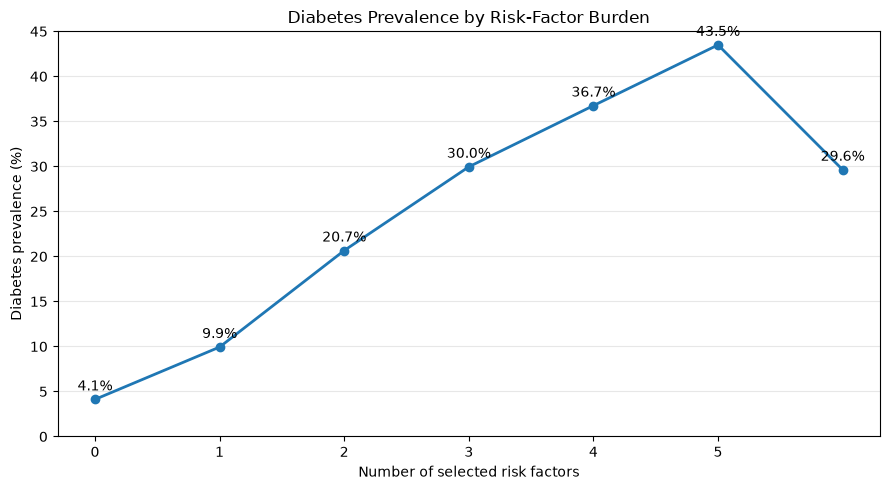

In [144]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    diabetes_by_risk.index,
    diabetes_by_risk.values,
    marker="o",
    linewidth=2
)

for x, y in zip(diabetes_by_risk.index, diabetes_by_risk.values):
    plt.text(x, y + 1, f"{y:.1f}%", ha="center")

plt.xlabel("Number of selected risk factors")
plt.ylabel("Diabetes prevalence (%)")
plt.title("Diabetes Prevalence by Risk-Factor Burden")

plt.xticks(range(6))
plt.ylim(0, 45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [145]:

bmi_percent = pd.crosstab(
    df["BMI_Category"],
    df["Diabetes_012"],
    normalize="index"
) * 100

diabetes_by_bmi = bmi_percent[2.0]

In [146]:
diabetes_by_bmi

BMI_Category
Underweight      5.404541
Normal           6.247459
Overweight      12.682065
Obesity I       21.152678
Obesity II      28.531073
Obesity III+    33.826988
Name: 2.0, dtype: float64

In [114]:
bmi_bp = pd.crosstab(
    [df["BMI_Category"], df["HighBP"]],
    df["Diabetes_012"],
    normalize="index"
) * 100

In [115]:
bmi_bp

Diabetes_012               0.0       1.0        2.0
BMI_Category HighBP                                
Underweight  0.0     96.443044  0.810446   2.746511
             1.0     86.975717  1.103753  11.920530
Normal       0.0     96.142316  0.764289   3.093395
             1.0     84.398755  1.811808  13.789436
Overweight   0.0     92.651958  1.189403   6.158639
             1.0     76.468537  2.555926  20.975537
Obesity I    0.0     87.996812  1.698376  10.304811
             1.0     66.678974  3.232821  30.088205
Obesity II   0.0     83.661097  2.617182  13.721721
             1.0     58.253803  3.751299  37.994897
Obesity III+ 0.0     80.865266  2.744129  16.390606
             1.0     53.564703  3.120796  43.314501

In [116]:
diabetes_bmi_bp = bmi_bp[2.0].unstack()

In [117]:
diabetes_bmi_bp

HighBP,0.0,1.0
BMI_Category,,
Underweight,2.746511,11.920530
Normal,3.093395,13.789436
Overweight,6.158639,20.975537
Obesity I,10.304811,30.088205
Obesity II,13.721721,37.994897
Obesity III+,16.390606,43.314501


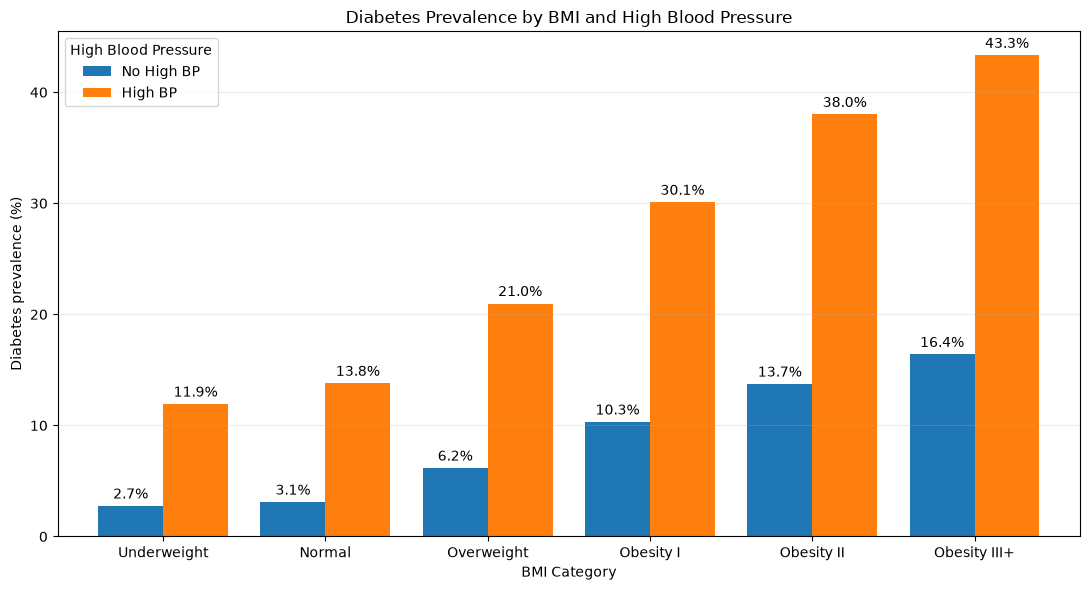

In [118]:
import matplotlib.pyplot as plt

ax = diabetes_bmi_bp.plot(
    kind="bar",
    figsize=(11, 6),
    width=0.8
)

plt.xlabel("BMI Category")
plt.ylabel("Diabetes prevalence (%)")
plt.title("Diabetes Prevalence by BMI and High Blood Pressure")
plt.xticks(rotation=0)

plt.legend(
    ["No High BP", "High BP"],
    title="High Blood Pressure"
)

plt.grid(axis="y", alpha=0.25)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

In [119]:
%whos

Variable                 Type                      Data/Info
------------------------------------------------------------
DecisionTreeClassifier   ABCMeta                   <class 'sklearn.tree._cla<...>.DecisionTreeClassifier'>
GridSearchCV             ABCMeta                   <class 'sklearn.model_sel<...>on._search.GridSearchCV'>
KNeighborsClassifier     ABCMeta                   <class 'sklearn.neighbors<...>on.KNeighborsClassifier'>
LogisticRegression       type                      <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
Pipeline                 ABCMeta                   <class 'sklearn.pipeline.Pipeline'>
RandomForestClassifier   ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
SVC                      ABCMeta                   <class 'sklearn.svm._classes.SVC'>
SelectKBest              ABCMeta                   <class 'sklearn.feature_s<...>e_selection.SelectKBest'>
StandardScaler           type                      <class 'skle

In [120]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'C': 0.01}
0.7816227856321261


In [121]:
lr_tuned = grid_search.best_estimator_

lr_tuned_pred = lr_tuned.predict(X_test_fe_scaled)

print(classification_report(y_test, lr_tuned_pred))

              precision    recall  f1-score   support

         0.0       0.86      0.98      0.91     42741
         1.0       0.00      0.00      0.00       926
         2.0       0.51      0.17      0.25      7069

    accuracy                           0.85     50736
   macro avg       0.46      0.38      0.39     50736
weighted avg       0.80      0.85      0.81     50736



/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [122]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, lr_tuned_pred)

print(cm_lr)

[[41702     0  1039]
 [  836     0    90]
 [ 5874     0  1195]]


In [123]:
print(models)

{'LogisticRegression': array([0., 0., 0., ..., 2., 0., 0.], shape=(50736,)), 'KNN': array([0., 0., 0., ..., 2., 0., 0.], shape=(50736,)), 'Decision Tree': array([0., 0., 0., ..., 2., 0., 0.], shape=(50736,)), 'Random Forest': array([0., 0., 0., ..., 2., 0., 0.], shape=(50736,))}


In [124]:
print(grid_search.best_estimator_)

LogisticRegression(C=0.01, max_iter=1000, random_state=42)


In [125]:
for name in list(globals()):
    value = globals()[name]
    if type(value).__name__ == "GridSearchCV":
        print(name, "→", value.estimator)

grid_search → LogisticRegression(max_iter=1000, random_state=42)
_61 → LogisticRegression(max_iter=1000, random_state=42)
grid_search_lr → Pipeline(steps=[('scaler', StandardScaler()),
                ('lr', LogisticRegression(max_iter=1000, random_state=42))])
_77 → Pipeline(steps=[('scaler', StandardScaler()),
                ('lr', LogisticRegression(max_iter=1000, random_state=42))])
rf_grid → RandomForestClassifier(n_jobs=-1, random_state=42)
dt_grid → DecisionTreeClassifier(random_state=42)
_93 → DecisionTreeClassifier(random_state=42)


In [126]:
for name in list(globals()):
    value = globals()[name]
    if "rf" in name.lower() or "random" in name.lower():
        print(name, type(value).__name__)

RandomForestClassifier ABCMeta
rf_model RandomForestClassifier
rf_predictions ndarray
rf_prob ndarray
rf_auc float
rf_class_auc ndarray
rf RandomForestClassifier
rf_param_grid dict
rf_grid GridSearchCV
best_rf RandomForestClassifier
rf_tuned_pred ndarray
rf_tuned_prob ndarray
rf_tuned_roc_auc float
rf_fe RandomForestClassifier
rf_fe_prob ndarray
rf_fe_roc_auc float


In [127]:
print("Tuned LR:", grid_search.best_params_)
print("Tuned LR ROC-AUC:", grid_search.best_score_)

Tuned LR: {'C': 0.01}
Tuned LR ROC-AUC: 0.7816227856321261


In [128]:
print(X_train_fe2_scaled.shape)
print(X_test_fe2_scaled.shape)

(202944, 27)
(50736, 27)


In [129]:
for name, value in globals().items():
    if "GridSearch" in str(type(value)):
        print(name, "→", type(value))

grid_search → <class 'sklearn.model_selection._search.GridSearchCV'>
_61 → <class 'sklearn.model_selection._search.GridSearchCV'>
grid_search_lr → <class 'sklearn.model_selection._search.GridSearchCV'>
_77 → <class 'sklearn.model_selection._search.GridSearchCV'>
rf_grid → <class 'sklearn.model_selection._search.GridSearchCV'>
dt_grid → <class 'sklearn.model_selection._search.GridSearchCV'>
_93 → <class 'sklearn.model_selection._search.GridSearchCV'>


In [130]:
print("grid_search")
print(grid_search.best_params_)
print(grid_search.best_score_)

print("\n_54")
print(_54.best_params_)
print(_54.best_score_)

grid_search
{'C': 0.01}
0.7816227856321261

_54


NameError: name '_54' is not defined

In [131]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dt_model = DecisionTreeClassifier(random_state=42)

dt_param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_leaf": [1, 5, 10, 20]
}

dt_grid = GridSearchCV(
    dt_model,
    dt_param_grid,
    cv=5,
    scoring="roc_auc_ovr",
    n_jobs=-1
)

dt_grid.fit(X_train_fe_scaled, y_train)

print("Best Parameters:", dt_grid.best_params_)
print("Best CV ROC-AUC:", dt_grid.best_score_)

Best Parameters: {'max_depth': 7, 'min_samples_leaf': 1}
Best CV ROC-AUC: 0.7692256825209115


In [132]:
from sklearn.metrics import classification_report, confusion_matrix

dt_tuned = dt_grid.best_estimator_

dt_tuned_pred = dt_tuned.predict(X_test_fe_scaled)

print("Classification Report:")
print(classification_report(y_test, dt_tuned_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, dt_tuned_pred))

Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.98      0.92     42741
         1.0       0.00      0.00      0.00       926
         2.0       0.55      0.13      0.21      7069

    accuracy                           0.85     50736
   macro avg       0.47      0.37      0.38     50736
weighted avg       0.80      0.85      0.80     50736

Confusion Matrix:
[[42054     0   687]
 [  855     0    71]
 [ 6147     0   922]]


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

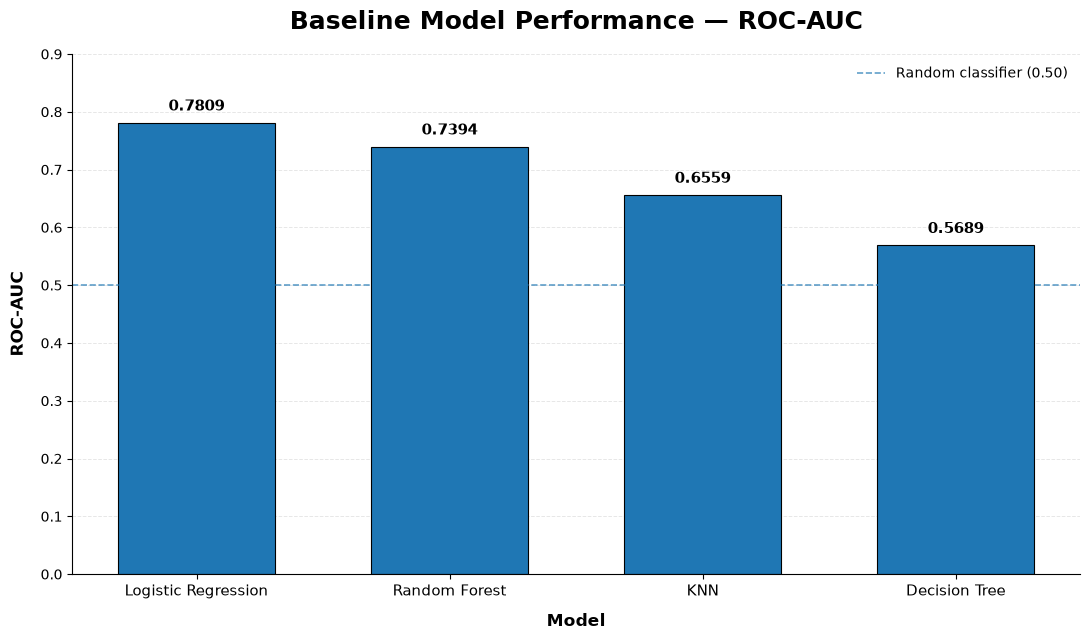

In [133]:
import matplotlib.pyplot as plt
import numpy as np

# Baseline ROC-AUC values
models = [
    "Logistic Regression",
    "KNN",
    "Decision Tree",
    "Random Forest"
]

roc_auc = [
    0.7808737384,
    0.6558521124,
    0.5689155517,
    0.7394045915
]

# Sort from highest to lowest ROC-AUC
order = np.argsort(roc_auc)[::-1]

models_sorted = np.array(models)[order]
roc_sorted = np.array(roc_auc)[order]

# Create figure
fig, ax = plt.subplots(figsize=(11, 6.5))

# Bars
bars = ax.bar(
    models_sorted,
    roc_sorted,
    width=0.62,
    edgecolor="black",
    linewidth=0.8
)

# Add exact values
for bar, value in zip(bars, roc_sorted):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.015,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Random classifier reference
ax.axhline(
    y=0.50,
    linestyle="--",
    linewidth=1.2,
    alpha=0.7,
    label="Random classifier (0.50)"
)

# Title
ax.set_title(
    "Baseline Model Performance — ROC-AUC",
    fontsize=18,
    fontweight="bold",
    pad=18
)

# Axis labels
ax.set_xlabel(
    "Model",
    fontsize=12,
    fontweight="bold",
    labelpad=10
)

ax.set_ylabel(
    "ROC-AUC",
    fontsize=12,
    fontweight="bold",
    labelpad=10
)

# Y-axis
ax.set_ylim(0, 0.9)
ax.set_yticks(np.arange(0, 0.91, 0.1))

# Grid
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.3
)

ax.set_axisbelow(True)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend
ax.legend(
    frameon=False,
    loc="upper right"
)

# Tick formatting
plt.xticks(fontsize=11)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

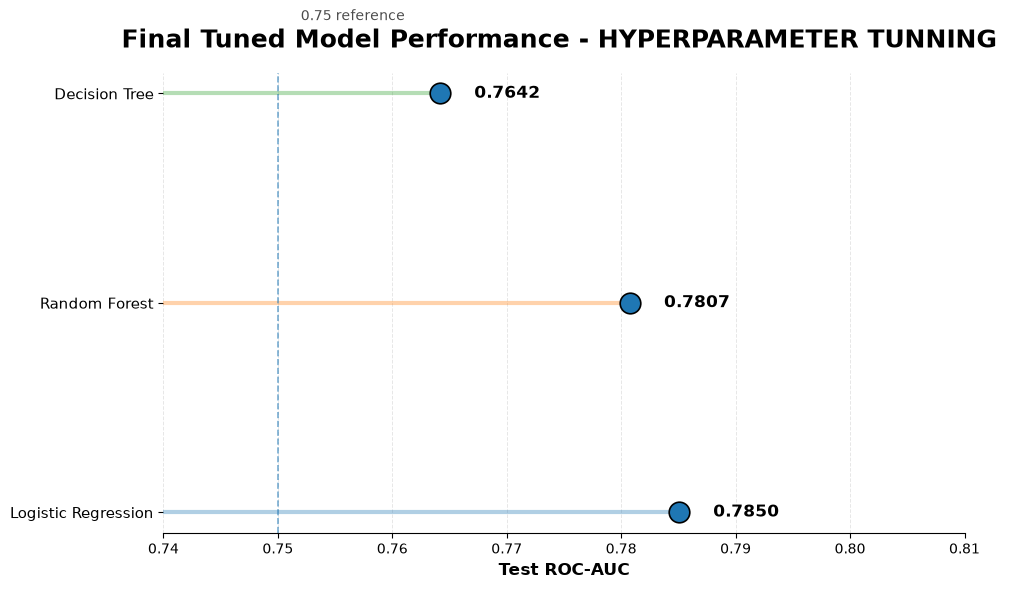

In [134]:
import matplotlib.pyplot as plt
import numpy as np

# Final tuned test ROC-AUC
models = [
    "Logistic Regression",
    "Random Forest",
    "Decision Tree"
]

roc_auc = [
    0.7850404163,
    0.7807430326,
    0.7641611362
]

# Sort best → worst
order = np.argsort(roc_auc)[::-1]
models = np.array(models)[order]
roc_auc = np.array(roc_auc)[order]

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Horizontal stems
for i, value in enumerate(roc_auc):
    ax.plot(
        [0.74, value],
        [i, i],
        linewidth=3,
        alpha=0.35
    )

# Main points
ax.scatter(
    roc_auc,
    range(len(models)),
    s=220,
    zorder=3,
    edgecolor="black",
    linewidth=1.2
)

# Add exact ROC-AUC values
for i, value in enumerate(roc_auc):
    ax.text(
        value + 0.003,
        i,
        f"{value:.4f}",
        va="center",
        fontsize=12,
        fontweight="bold"
    )

# Reference line
ax.axvline(
    0.75,
    linestyle="--",
    linewidth=1.2,
    alpha=0.6
)

ax.text(
    0.752,
    2.35,
    "0.75 reference",
    fontsize=10,
    alpha=0.7
)

# Labels
ax.set_yticks(range(len(models)))
ax.set_yticklabels(models, fontsize=11)

ax.set_xlabel(
    "Test ROC-AUC",
    fontsize=12,
    fontweight="bold"
)

ax.set_title(
    "Final Tuned Model Performance - HYPERPARAMETER TUNNING ",
    fontsize=18,
    fontweight="bold",
    pad=18
)

# X-axis
ax.set_xlim(0.74, 0.81)
ax.set_xticks(np.arange(0.74, 0.811, 0.01))

# Grid
ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.7,
    alpha=0.3
)

ax.set_axisbelow(True)

# Clean frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

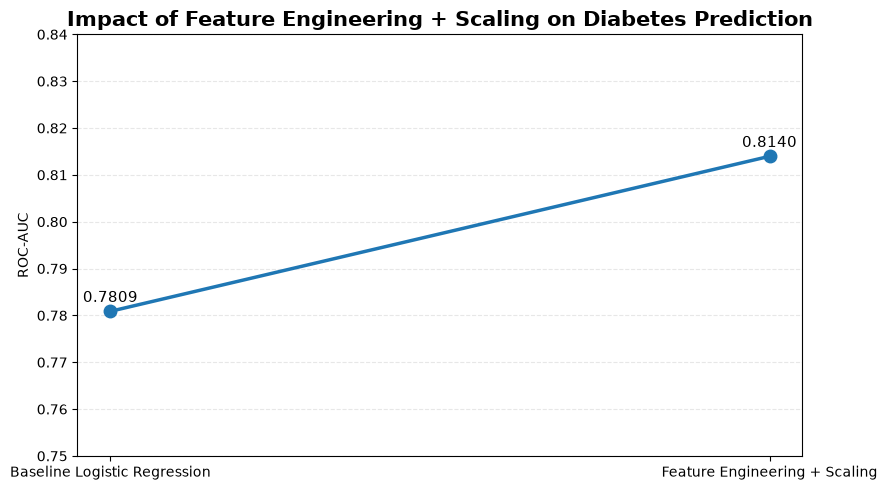

In [135]:
import matplotlib.pyplot as plt

models = [
    "Baseline Logistic Regression",
    "Feature Engineering + Scaling"
]

roc_auc = [
    0.7808737384,
    0.8139634213
]

plt.figure(figsize=(9, 5))

plt.plot(
    models,
    roc_auc,
    marker="o",
    linewidth=2.5,
    markersize=9
)

for i, value in enumerate(roc_auc):
    plt.text(
        i,
        value + 0.002,
        f"{value:.4f}",
        ha="center",
        fontsize=11
    )

plt.title(
    "Impact of Feature Engineering + Scaling on Diabetes Prediction",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("ROC-AUC")
plt.ylim(0.75, 0.84)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

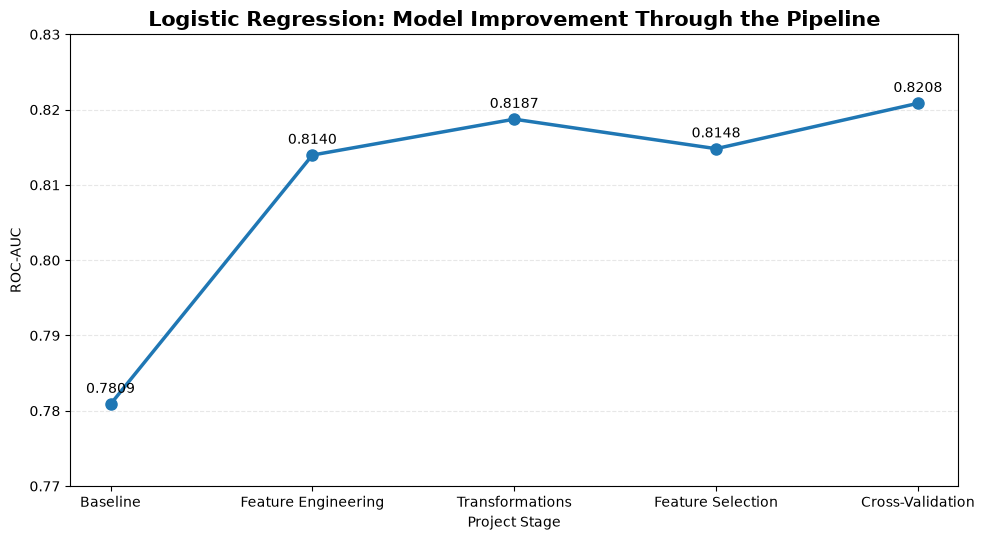

In [136]:
import matplotlib.pyplot as plt

stages = [
    "Baseline",
    "Feature Engineering",
    "Transformations",
    "Feature Selection",
    "Cross-Validation"
]

roc_auc = [
    0.7808737384,
    0.8139634213,
    0.81873,
    0.81481,
    0.82084
]

plt.figure(figsize=(10, 5.5))

plt.plot(
    stages,
    roc_auc,
    marker="o",
    linewidth=2.5,
    markersize=8
)

# Add ROC-AUC values above each point
for i, value in enumerate(roc_auc):
    plt.text(
        i,
        value + 0.0015,
        f"{value:.4f}",
        ha="center",
        fontsize=10
    )

plt.title(
    "Logistic Regression: Model Improvement Through the Pipeline",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Project Stage")
plt.ylabel("ROC-AUC")

plt.ylim(0.77, 0.83)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [150]:
from sklearn.metrics import classification_report
import numpy as np

# Convert predicted probabilities into predicted classes
y_pred_final = np.argmax(best_lr_prob, axis=1)

# Final classification report
print("Tuned Logistic Regression - Classification Report\n")
print(classification_report(y_test, y_pred_final))

Tuned Logistic Regression - Classification Report

              precision    recall  f1-score   support

         0.0       0.86      0.98      0.92     42741
         1.0       0.00      0.00      0.00       926
         2.0       0.54      0.19      0.28      7069

    accuracy                           0.85     50736
   macro avg       0.47      0.39      0.40     50736
weighted avg       0.80      0.85      0.81     50736



/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [151]:
from sklearn.metrics import classification_report
import numpy as np

# Logistic Regression
lr_pred = np.argmax(best_lr_prob, axis=1)

print("===== TUNED LOGISTIC REGRESSION =====")
print(classification_report(y_test, lr_pred))


# Random Forest
rf_pred = np.argmax(rf_tuned_prob, axis=1)

print("===== TUNED RANDOM FOREST =====")
print(classification_report(y_test, rf_pred))


# Decision Tree
dt_pred = np.argmax(dt_tuned_prob, axis=1)

print("===== TUNED DECISION TREE =====")
print(classification_report(y_test, dt_pred))

===== TUNED LOGISTIC REGRESSION =====
              precision    recall  f1-score   support

         0.0       0.86      0.98      0.92     42741
         1.0       0.00      0.00      0.00       926
         2.0       0.54      0.19      0.28      7069

    accuracy                           0.85     50736
   macro avg       0.47      0.39      0.40     50736
weighted avg       0.80      0.85      0.81     50736

===== TUNED RANDOM FOREST =====
              precision    recall  f1-score   support

         0.0       0.86      0.99      0.92     42741
         1.0       0.00      0.00      0.00       926
         2.0       0.58      0.14      0.22      7069

    accuracy                           0.85     50736
   macro avg       0.48      0.37      0.38     50736
weighted avg       0.80      0.85      0.80     50736

===== TUNED DECISION TREE =====
              precision    recall  f1-score   support

         0.0       0.86      0.98      0.92     42741
         1.0       0.00    

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha